In [40]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
system_content

'You are one of roughly 500 Americans scientifically selected to represent the entire country on September 19-22 2019.you will join your fellow Americans in discussing the issues confronting the USYour Goal: Listen to others and decide if your opinion changes.\n\nLIKERT SCALE:\n0 = Extremely oppose\n1 = Very strongly oppose\n2 = Strongly oppose\n3 = Moderately oppose\n4 = Slightly oppose\n5 = Neutral / Do not oppose or favor\n6 = Slightly favor\n7 = Moderately favor\n8 = Strongly favor\n9 = Very strongly favor\n10 = Extremely favor'

In [2]:
# Load data from JSON file
with open('results/simulation_results_prelim.json', 'r') as f:
    results = json.load(f)

In [3]:
results

{'Group_1_Q1': {'arguments': {'0': "I would rate my opinion on the system of democracy in the US as a 5, neutral/do not oppose or favor. I hold this position because I believe that the system has its flaws, but it also has its strengths. For instance, the system allows for the peaceful transfer of power, which is a fundamental aspect of democracy, but at the same time, it can be slow to adapt to changing circumstances and is often influenced by special interest groups. Overall, I think the system is a work in progress and needs to be refined, but it's not entirely broken.  (5)",
   '17': 'I would say the system of democracy in the US works moderately well these days. I moderately favor the current state of democracy in the US because I believe that the system has checks and balances that prevent any one group or individual from abusing power, and I also believe that the US has a strong tradition of protecting individual rights and freedoms. However, I also think that there are some iss

In [5]:
with open('simulation_resources/participant_attitudes.json', 'r') as f:
    participants = json.load(f)

In [ ]:
participants

In [14]:
df = []
for participant in participants:
    pid = participant['id']
    if participant['group'] == 1:
        for question in participant['questions'].keys():
            row = {}
            row['id'] = pid
            row["question"] = question
            row["before_attitude"] = participant['questions'][question]
            groupIndex = "Group_1_" + question
            row["after_attitude"] = results[groupIndex]['rankings'][str(pid)]
            df.append(row)

In [50]:
df = pd.DataFrame(df)

In [21]:
question_df = pd.read_csv("clean_data/question_level_master_dataset.csv")

In [46]:
question_df.shape

(25104, 16)

In [53]:
compare_df = df.merge(question_df, left_on=["id","question"], right_on=['ID',"Question"], how="left")

In [54]:
compare_df.shape

(672, 20)

In [55]:
compare_df.drop(columns=["id","question","before_attitude","BeforeResponse","AfterResponse"], inplace=True)

In [56]:
compare_df.rename(columns={"after_attitude":"LLMNumber"}, inplace=True)

In [57]:
compare_df

,LLMNumber,ID,Question,QuestionText,Topic,ValidResponse,BeforeNumber,AfterNumber,GROUP,RACE,AGEBRACKET,EDUCATION,PARTYBEFORE,GENDER,AGE
0,6.0,0,Q1,How poorly or well would you say the system of...,Democracy,True,5,9,1,"White, non-Hispanic",18-29,Some college,Independent,Male,21
1,2.0,0,Q2A,[Reduce the number of refuges allowed to reset...,Immigration,True,0,2,1,"White, non-Hispanic",18-29,Some college,Independent,Male,21
2,10.0,0,Q2B,[Increase personnel to process asylum seekers'...,Immigration,True,10,10,1,"White, non-Hispanic",18-29,Some college,Independent,Male,21
3,0.0,0,Q2C,[Provide aid to reduce poverty and violence in...,Immigration,True,0,7,1,"White, non-Hispanic",18-29,Some college,Independent,Male,21
4,5.0,0,Q2D,[Increase the number of visas for skilled work...,Immigration,True,5,10,1,"White, non-Hispanic",18-29,Some college,Independent,Male,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,10.0,515,Q6F,[The US should recommit to the Iran Nuclear Ag...,Global Position,True,10,10,1,"White, non-Hispanic",60+,Some college,Democrat,Female,72
668,10.0,515,Q6G,[Presidents should be required to obtain expli...,Global Position,True,10,10,1,"White, non-Hispanic",60+,Some college,Democrat,Female,72
669,9.0,515,Q6H,[The U.S. should intervene abroad when it is n...,Global Position,True,8,8,1,"White, non-Hispanic",60+,Some college,Democrat,Female,72
670,4.0,515,Q6I,[The U.S. should increase military spending by...,Global Position,True,5,0,1,"White, non-Hispanic",60+,Some college,Democrat,Female,72


In [74]:
compare_df["ABS_DIFF"] = abs(compare_df["LLMNumber"] - compare_df["AfterNumber"])
compare_df["DIFF"] = (compare_df["LLMNumber"] - compare_df["AfterNumber"])

In [65]:
# filter out rows where LLMNumber, BeforeNumber, or AfterNumber is 77 98 or 99
compare_df = compare_df[~compare_df["LLMNumber"].isin([77,98,99])]
compare_df = compare_df[~compare_df["AfterNumber"].isin([77,98,99])]
compare_df = compare_df[~compare_df["BeforeNumber"].isin([77,98,99])]

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47],
 [Text(0, 0, 'Q1'),
  Text(1, 0, 'Q2A'),
  Text(2, 0, 'Q2B'),
  Text(3, 0, 'Q2C'),
  Text(4, 0, 'Q2D'),
  Text(5, 0, 'Q2E'),
  Text(6, 0, 'Q2F'),
  Text(7, 0, 'Q2G'),
  Text(8, 0, 'Q2H'),
  Text(9, 0, 'Q2I'),
  Text(10, 0, 'Q3A'),
  Text(11, 0, 'Q3B'),
  Text(12, 0, 'Q3C'),
  Text(13, 0, 'Q3D'),
  Text(14, 0, 'Q3E'),
  Text(15, 0, 'Q3F'),
  Text(16, 0, 'Q3G'),
  Text(17, 0, 'Q3H'),
  Text(18, 0, 'Q4A'),
  Text(19, 0, 'Q4B'),
  Text(20, 0, 'Q4C'),
  Text(21, 0, 'Q4D'),
  Text(22, 0, 'Q4E'),
  Text(23, 0, 'Q4F'),
  Text(24, 0, 'Q4G'),
  Text(25, 0, 'Q4H'),
  Text(26, 0, 'Q4I'),
  Text(27, 0, 'Q4J'),
  Text(28, 0, 'Q5A'),
  Text(29, 0, 'Q5B'),
  Text(30, 0, 'Q5C'),
  Text(31, 0, 'Q5D'),
  Text(32, 0, 'Q5E'),
  Text

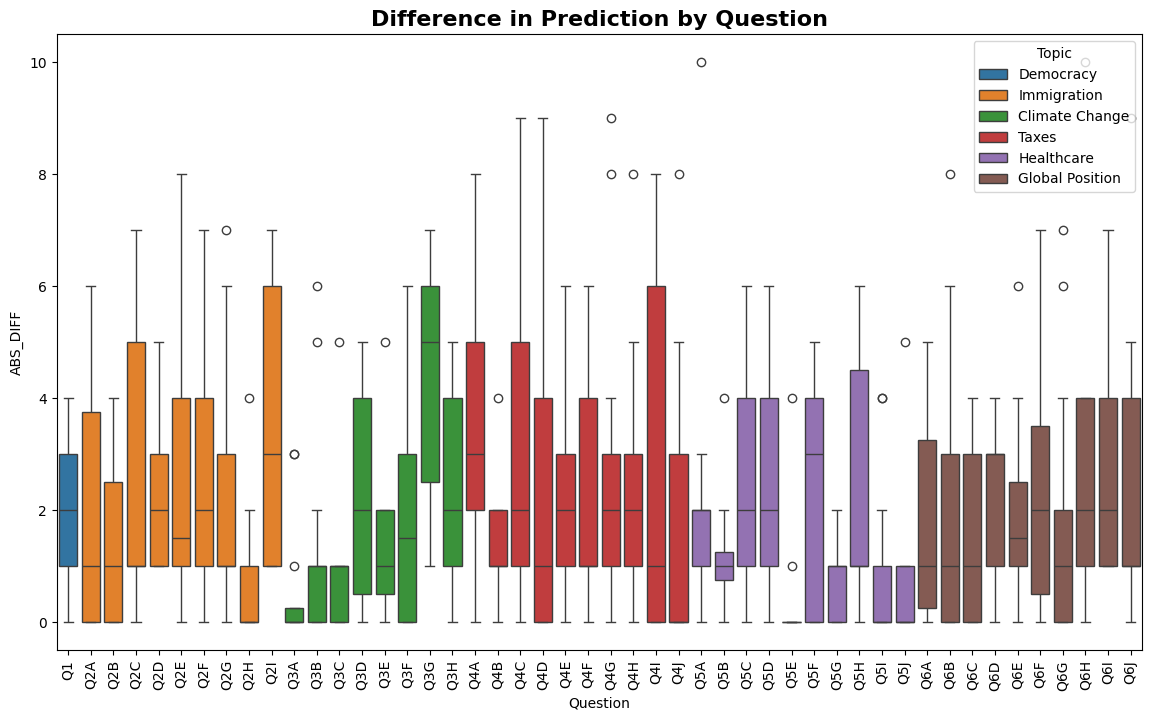

In [69]:
fig = plt.figure(figsize=(14, 8))
sns.boxplot(data=compare_df, x='Question', y='ABS_DIFF', hue='Topic')
plt.title('Difference in Prediction by Question', fontsize=16, fontweight='bold')
plt.ylim(-0.5,10.5)
plt.xticks(rotation=90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47],
 [Text(0, 0, 'Q1'),
  Text(1, 0, 'Q2A'),
  Text(2, 0, 'Q2B'),
  Text(3, 0, 'Q2C'),
  Text(4, 0, 'Q2D'),
  Text(5, 0, 'Q2E'),
  Text(6, 0, 'Q2F'),
  Text(7, 0, 'Q2G'),
  Text(8, 0, 'Q2H'),
  Text(9, 0, 'Q2I'),
  Text(10, 0, 'Q3A'),
  Text(11, 0, 'Q3B'),
  Text(12, 0, 'Q3C'),
  Text(13, 0, 'Q3D'),
  Text(14, 0, 'Q3E'),
  Text(15, 0, 'Q3F'),
  Text(16, 0, 'Q3G'),
  Text(17, 0, 'Q3H'),
  Text(18, 0, 'Q4A'),
  Text(19, 0, 'Q4B'),
  Text(20, 0, 'Q4C'),
  Text(21, 0, 'Q4D'),
  Text(22, 0, 'Q4E'),
  Text(23, 0, 'Q4F'),
  Text(24, 0, 'Q4G'),
  Text(25, 0, 'Q4H'),
  Text(26, 0, 'Q4I'),
  Text(27, 0, 'Q4J'),
  Text(28, 0, 'Q5A'),
  Text(29, 0, 'Q5B'),
  Text(30, 0, 'Q5C'),
  Text(31, 0, 'Q5D'),
  Text(32, 0, 'Q5E'),
  Text

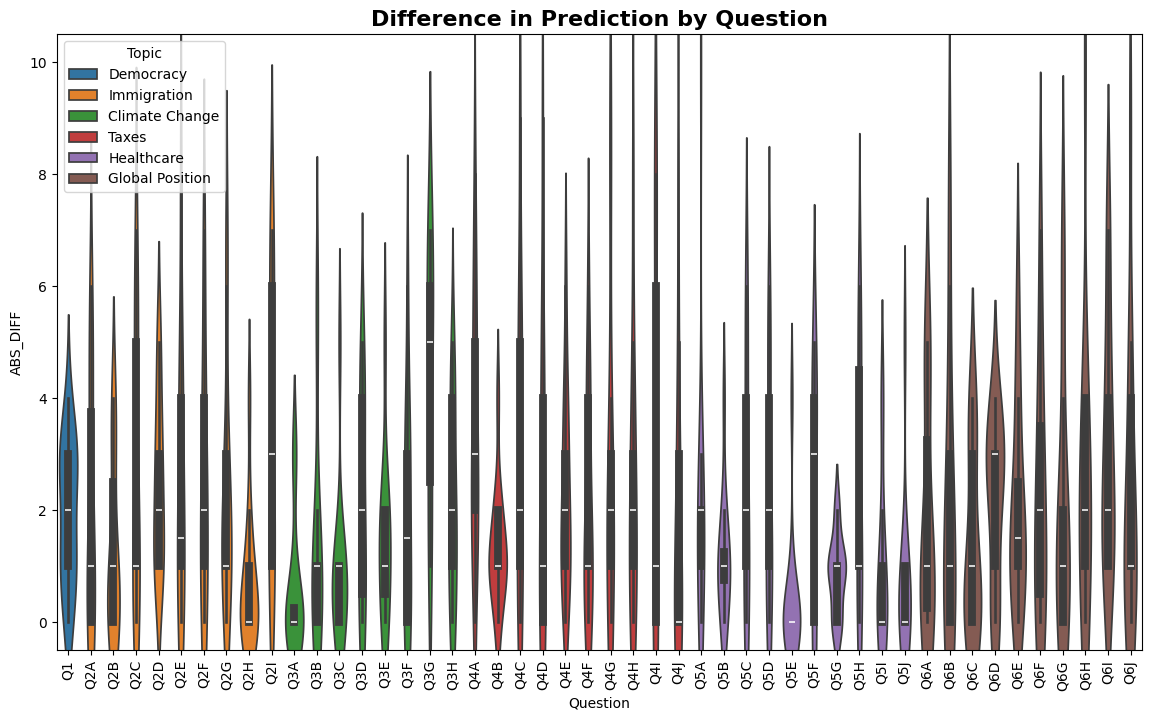

In [73]:
fig = plt.figure(figsize=(14, 8))
sns.violinplot(data=compare_df, x='Question', y='ABS_DIFF', hue='Topic')
plt.title('Difference in Prediction by Question', fontsize=16, fontweight='bold')
plt.ylim(-0.5,10.5)
plt.xticks(rotation=90)

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_41000/1155802422.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


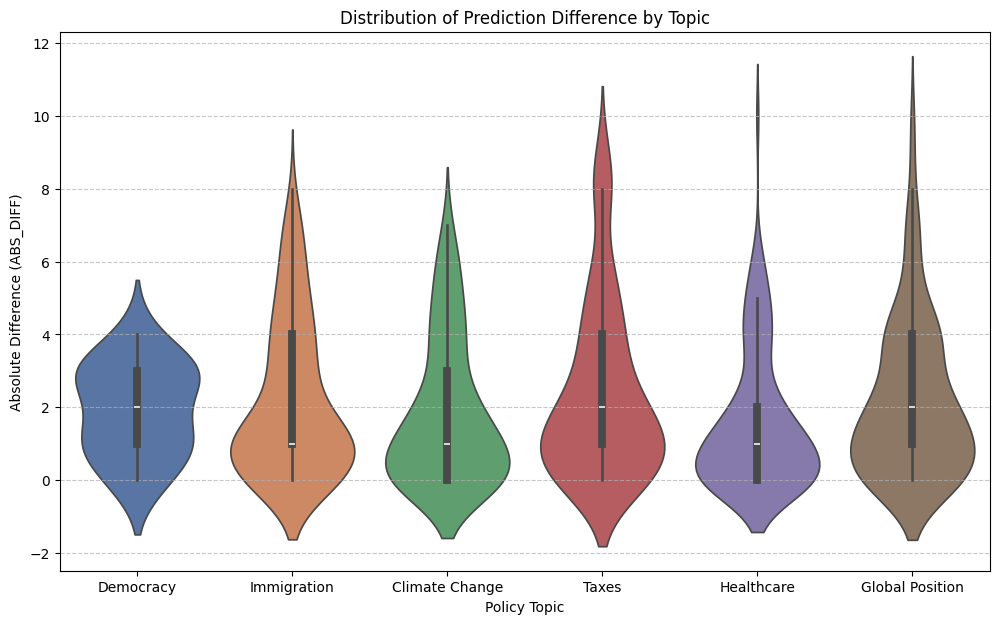

In [72]:
# Assuming your data is loaded into a Pandas DataFrame called 'df'
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Create the Box Plot
sns.violinplot(
    x='Topic',         # Use Topic as the categorical axis
    y='ABS_DIFF',      # Use ABS_DIFF as the continuous distribution axis
    data=compare_df,
    palette='deep'     # Use a distinct color palette
)

plt.title('Distribution of Prediction Difference by Topic')
plt.xlabel('Policy Topic')
plt.ylabel('Absolute Difference (ABS_DIFF)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_41000/878779666.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


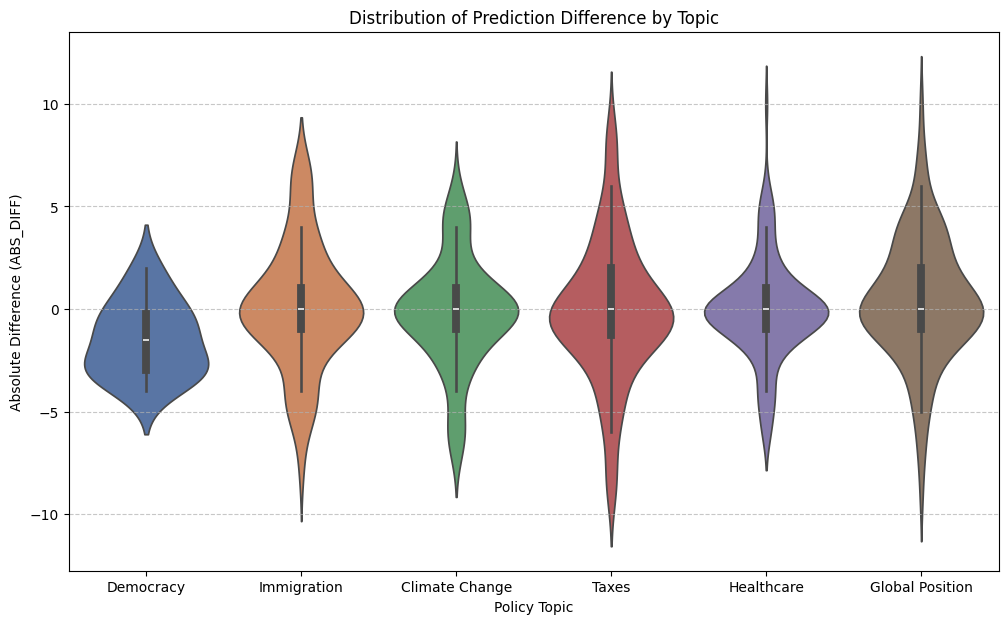

In [75]:
# Assuming your data is loaded into a Pandas DataFrame called 'df'
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Create the Box Plot
sns.violinplot(
    x='Topic',         # Use Topic as the categorical axis
    y='DIFF',      # Use ABS_DIFF as the continuous distribution axis
    data=compare_df,
    palette='deep'     # Use a distinct color palette
)

plt.title('Distribution of Prediction Difference by Topic')
plt.xlabel('Policy Topic')
plt.ylabel('Absolute Difference (ABS_DIFF)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47],
 [Text(0, 0, 'Q1'),
  Text(1, 0, 'Q2A'),
  Text(2, 0, 'Q2B'),
  Text(3, 0, 'Q2C'),
  Text(4, 0, 'Q2D'),
  Text(5, 0, 'Q2E'),
  Text(6, 0, 'Q2F'),
  Text(7, 0, 'Q2G'),
  Text(8, 0, 'Q2H'),
  Text(9, 0, 'Q2I'),
  Text(10, 0, 'Q3A'),
  Text(11, 0, 'Q3B'),
  Text(12, 0, 'Q3C'),
  Text(13, 0, 'Q3D'),
  Text(14, 0, 'Q3E'),
  Text(15, 0, 'Q3F'),
  Text(16, 0, 'Q3G'),
  Text(17, 0, 'Q3H'),
  Text(18, 0, 'Q4A'),
  Text(19, 0, 'Q4B'),
  Text(20, 0, 'Q4C'),
  Text(21, 0, 'Q4D'),
  Text(22, 0, 'Q4E'),
  Text(23, 0, 'Q4F'),
  Text(24, 0, 'Q4G'),
  Text(25, 0, 'Q4H'),
  Text(26, 0, 'Q4I'),
  Text(27, 0, 'Q4J'),
  Text(28, 0, 'Q5A'),
  Text(29, 0, 'Q5B'),
  Text(30, 0, 'Q5C'),
  Text(31, 0, 'Q5D'),
  Text(32, 0, 'Q5E'),
  Text

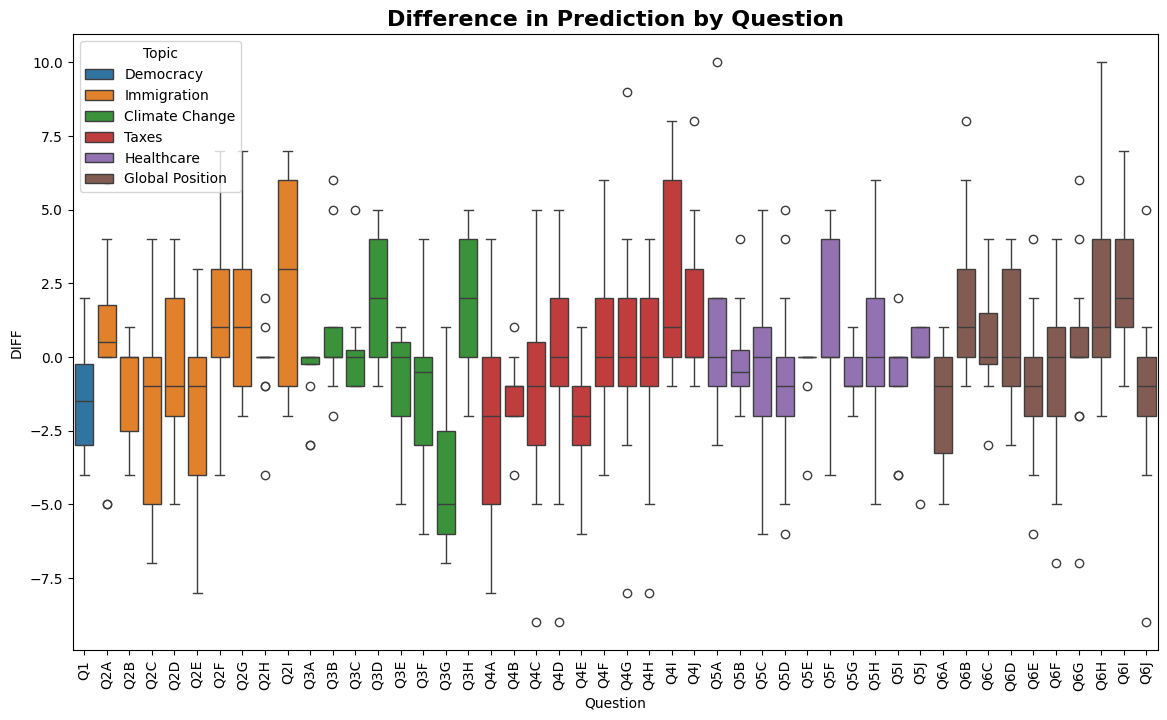

In [77]:
fig = plt.figure(figsize=(14, 8))
sns.boxplot(data=compare_df, x='Question', y='DIFF', hue='Topic')
plt.title('Difference in Prediction by Question', fontsize=16, fontweight='bold')
plt.xticks(rotation=90)

In [80]:
! pip install scipy

  Obtaining dependency information for scipy from https://files.pythonhosted.org/packages/96/5e/36bf3f0ac298187d1ceadde9051177d6a4fe4d507e8f59067dc9dd39e650/scipy-1.16.3-cp312-cp312-macosx_14_0_arm64.whl.metadata
  Using cached scipy-1.16.3-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
Using cached scipy-1.16.3-cp312-cp312-macosx_14_0_arm64.whl (20.9 MB)

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [83]:
import pandas as pd
from scipy.stats import chi2_contingency

# Assume 'df' is your DataFrame
stats_df = []
for question in compare_df['Question'].unique():
    # Filter the data for a specific question
    row = {}
    question_data = compare_df[compare_df['Question'] == question]

    # ... proceed with the test on question_data ...

    # Create a contingency table
    contingency_table = pd.crosstab(question_data['LLMNumber'], question_data['AfterNumber'])

    # Perform the Chi-squared test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    # Interpret the result
    alpha = 0.05
    row['Question'] = question
    row['p_value'] = p_value
    if p_value < alpha:
        row['Significant'] = True
        #print("Same")
        #print("Result: Statistically significant relationship found. (Reject the null hypothesis of independence)")
    else:
        row['Significant'] = False
        #print("Different")
        #print("Result: No significant relationship found. (Fail to reject the null hypothesis of independence)")
    stats_df.append(row)
stats_df = pd.DataFrame(stats_df)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47],
 [Text(0, 0, 'Q1'),
  Text(1, 0, 'Q2A'),
  Text(2, 0, 'Q2B'),
  Text(3, 0, 'Q2C'),
  Text(4, 0, 'Q2D'),
  Text(5, 0, 'Q2E'),
  Text(6, 0, 'Q2F'),
  Text(7, 0, 'Q2G'),
  Text(8, 0, 'Q2H'),
  Text(9, 0, 'Q2I'),
  Text(10, 0, 'Q3A'),
  Text(11, 0, 'Q3B'),
  Text(12, 0, 'Q3C'),
  Text(13, 0, 'Q3D'),
  Text(14, 0, 'Q3E'),
  Text(15, 0, 'Q3F'),
  Text(16, 0, 'Q3G'),
  Text(17, 0, 'Q3H'),
  Text(18, 0, 'Q4A'),
  Text(19, 0, 'Q4B'),
  Text(20, 0, 'Q4C'),
  Text(21, 0, 'Q4D'),
  Text(22, 0, 'Q4E'),
  Text(23, 0, 'Q4F'),
  Text(24, 0, 'Q4G'),
  Text(25, 0, 'Q4H'),
  Text(26, 0, 'Q4I'),
  Text(27, 0, 'Q4J'),
  Text(28, 0, 'Q5A'),
  Text(29, 0, 'Q5B'),
  Text(30, 0, 'Q5C'),
  Text(31, 0, 'Q5D'),
  Text(32, 0, 'Q5E'),
  Text

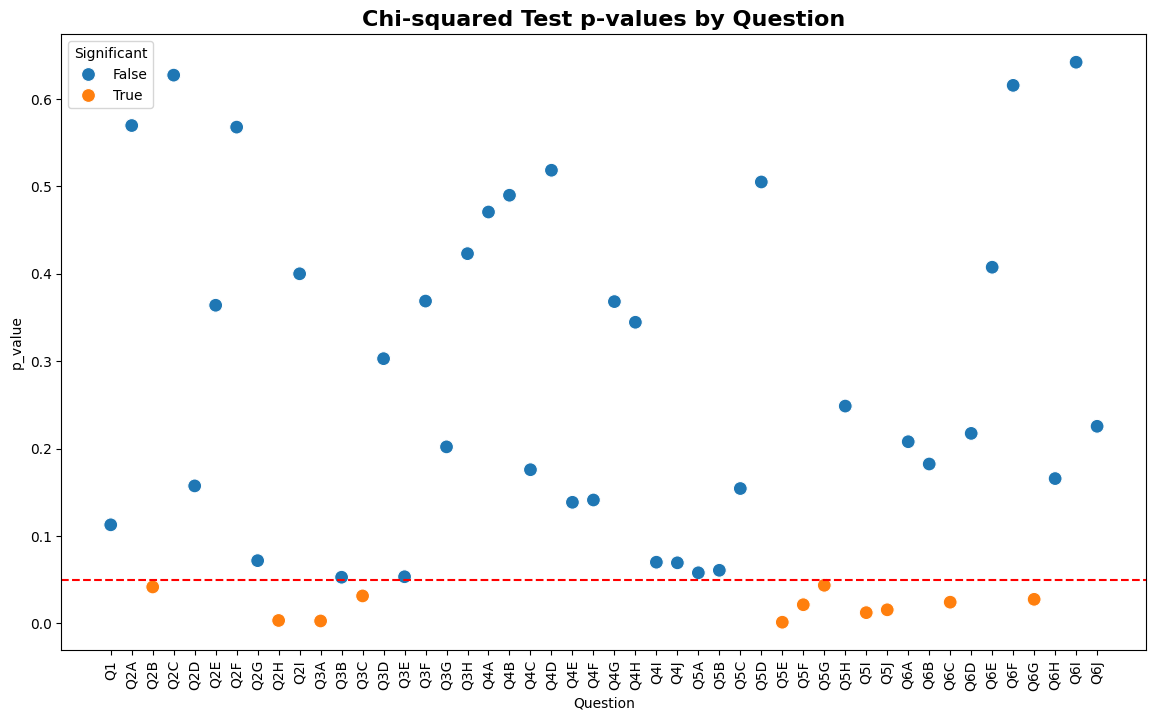

In [86]:
# plot p_values vs Questions with line at 0.05
fig = plt.figure(figsize=(14, 8))
sns.scatterplot(data=stats_df, x='Question', y='p_value', hue='Significant', s=100)
plt.axhline(0.05, color='red', linestyle='--')
plt.title('Chi-squared Test p-values by Question', fontsize=16, fontweight='bold')
plt.xticks(rotation=90)

In [2]:
participant

NameError: name 'participant' is not defined